# JSC270 Assignement 4
## Contributors:
Yukun Wang,
Patuan Purba,
Jack Li

In [ ]:
import re
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer, ENGLISH_STOP_WORDS

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix
from sklearn.utils.multiclass import unique_labels
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Part 1

In [ ]:
# Read the dataset
!git clone https://github.com/PatuanPurba/JSC270_Assignment4

%cd JSC270_Assignment4
covid_train = pd.read_csv('dataset/covid-tweets-train.csv')
covid_test = pd.read_csv('dataset/covid-tweets-test.csv')

Cloning into 'JSC270_Assignment4'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 36 (delta 14), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 12.28 MiB | 6.60 MiB/s, done.
Resolving deltas: 100% (14/14), done.
/content/JSC270_Assignment4/JSC270_Assignment4/JSC270_Assignment4/JSC270-HW4/JSC270_Assignment4/JSC270_Assignment4/JSC270_Assignment4/JSC270_Assignment4/JSC270-HW4/JSC270_Assignment4/JSC270-HW4/JSC270_Assignment4/JSC270-HW4/JSC270_Assignment4/JSC270_Assignment4


In [ ]:
# Drop rows with missing label
covid_train.dropna(inplace = True)
covid_test.dropna(inplace = True)

# Drop the extra column
covid_train.drop("Unnamed: 0", axis = 1, inplace = True)
covid_test.drop("Unnamed: 0", axis = 1, inplace = True)

# Convert the sentiment label into string
covid_train['Sentiment'] = covid_train['Sentiment'].astype(str)
covid_test['Sentiment'] = covid_test['Sentiment'].astype(str)

# Drop Invalid Sentiment Value
covid_train = covid_train[covid_train["Sentiment"].isin(['1', '2', '0'])]
covid_test = covid_test[covid_test["Sentiment"].isin(['1', '2', '0'])]

## A)

In [ ]:
# Calculate proportion for each labels
balance = covid_train["Sentiment"].value_counts().rename("balance") / len(covid_train)
balance.to_frame().T

Sentiment,2,0,1
balance,0.438434,0.374159,0.187407


## B)

In [ ]:
nltk.download('punkt_tab')
nltk.download("punkt")

# Tokenize the tweet for each observation on training and testing data
covid_train['Tokenized_tweets'] = covid_train['OriginalTweet'].astype(str).apply(nltk.word_tokenize)
covid_test['Tokenized_tweets'] = covid_test['OriginalTweet'].astype(str).apply(nltk.word_tokenize)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
# Rearrange the columns
new_columns = ["OriginalTweet", "Tokenized_tweets", 'Sentiment']
covid_train = covid_train[new_columns]
covid_test = covid_test[new_columns]

covid_train

,OriginalTweet,Tokenized_tweets,Sentiment
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,"[@, MeNyrbie, @, Phil_Gahan, @, Chrisitv, http...",1
1,advice Talk to your neighbours family to excha...,"[advice, Talk, to, your, neighbours, family, t...",2
2,Coronavirus Australia: Woolworths to give elde...,"[Coronavirus, Australia, :, Woolworths, to, gi...",2
3,My food stock is not the only one which is emp...,"[My, food, stock, is, not, the, only, one, whi...",2
4,"Me, ready to go at supermarket during the #COV...","[Me, ,, ready, to, go, at, supermarket, during...",0
...,...,...,...
41150,Airline pilots offering to stock supermarket s...,"[Airline, pilots, offering, to, stock, superma...",1
41151,Response to complaint not provided citing COVI...,"[Response, to, complaint, not, provided, citin...",0
41152,You know itÂs getting tough when @KameronWild...,"[You, know, itÂs, getting, tough, when, @, Ka...",2
41153,Is it wrong that the smell of hand sanitizer i...,"[Is, it, wrong, that, the, smell, of, hand, sa...",1


## C)

In [ ]:
# Define a function to remove url token from each observation
def removeurl(tokens):
    final_token = []
    for token in tokens:
        if not re.match(r'^http\S*', token):
            final_token.append(token)
    return final_token

# Remove tokens starting with 'http' using regex
covid_train['Tokenized_tweets'] = covid_train['Tokenized_tweets'].apply(removeurl)
covid_test['Tokenized_tweets'] = covid_test['Tokenized_tweets'].apply(removeurl)
covid_train

,OriginalTweet,Tokenized_tweets,Sentiment
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,"[@, MeNyrbie, @, Phil_Gahan, @, Chrisitv, :, /...",1
1,advice Talk to your neighbours family to excha...,"[advice, Talk, to, your, neighbours, family, t...",2
2,Coronavirus Australia: Woolworths to give elde...,"[Coronavirus, Australia, :, Woolworths, to, gi...",2
3,My food stock is not the only one which is emp...,"[My, food, stock, is, not, the, only, one, whi...",2
4,"Me, ready to go at supermarket during the #COV...","[Me, ,, ready, to, go, at, supermarket, during...",0
...,...,...,...
41150,Airline pilots offering to stock supermarket s...,"[Airline, pilots, offering, to, stock, superma...",1
41151,Response to complaint not provided citing COVI...,"[Response, to, complaint, not, provided, citin...",0
41152,You know itÂs getting tough when @KameronWild...,"[You, know, itÂs, getting, tough, when, @, Ka...",2
41153,Is it wrong that the smell of hand sanitizer i...,"[Is, it, wrong, that, the, smell, of, hand, sa...",1


## D)

In [ ]:
# Pattern that matches any non letter or whitespace character
pattern = r'[^\w\s]'

# Define a function to remove unwanted characters
def removecharacters(tokens):
    final_token = []
    for token in tokens:
        clean_token = re.sub(pattern, '', token).lower()
        if clean_token:  # only keep non-empty tokens
            final_token.append(clean_token)
    return final_token

# Remove the unwanted characters in each token
covid_train['Tokenized_tweets'] = covid_train['Tokenized_tweets'].apply(removecharacters)
covid_test['Tokenized_tweets'] = covid_test['Tokenized_tweets'].apply(removecharacters)
covid_train

,OriginalTweet,Tokenized_tweets,Sentiment
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,"[menyrbie, phil_gahan, chrisitv, tcoifz9fan2pa...",1
1,advice Talk to your neighbours family to excha...,"[advice, talk, to, your, neighbours, family, t...",2
2,Coronavirus Australia: Woolworths to give elde...,"[coronavirus, australia, woolworths, to, give,...",2
3,My food stock is not the only one which is emp...,"[my, food, stock, is, not, the, only, one, whi...",2
4,"Me, ready to go at supermarket during the #COV...","[me, ready, to, go, at, supermarket, during, t...",0
...,...,...,...
41150,Airline pilots offering to stock supermarket s...,"[airline, pilots, offering, to, stock, superma...",1
41151,Response to complaint not provided citing COVI...,"[response, to, complaint, not, provided, citin...",0
41152,You know itÂs getting tough when @KameronWild...,"[you, know, itâs, getting, tough, when, kamero...",2
41153,Is it wrong that the smell of hand sanitizer i...,"[is, it, wrong, that, the, smell, of, hand, sa...",1


## E)

In [ ]:
# Define a function to stem each token
def stem_tokens(tokens):
    """Apply Porter stemmer to each token."""
    stemmer = PorterStemmer()
    return [stemmer.stem(token) for token in tokens]

# Stem each token
covid_train['Tokenized_tweets'] = covid_train['Tokenized_tweets'].apply(stem_tokens)
covid_test['Tokenized_tweets'] = covid_test['Tokenized_tweets'].apply(stem_tokens)
covid_train

,OriginalTweet,Tokenized_tweets,Sentiment
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,"[menyrbi, phil_gahan, chrisitv, tcoifz9fan2pa,...",1
1,advice Talk to your neighbours family to excha...,"[advic, talk, to, your, neighbour, famili, to,...",2
2,Coronavirus Australia: Woolworths to give elde...,"[coronaviru, australia, woolworth, to, give, e...",2
3,My food stock is not the only one which is emp...,"[my, food, stock, is, not, the, onli, one, whi...",2
4,"Me, ready to go at supermarket during the #COV...","[me, readi, to, go, at, supermarket, dure, the...",0
...,...,...,...
41150,Airline pilots offering to stock supermarket s...,"[airlin, pilot, offer, to, stock, supermarket,...",1
41151,Response to complaint not provided citing COVI...,"[respons, to, complaint, not, provid, cite, co...",0
41152,You know itÂs getting tough when @KameronWild...,"[you, know, itâ, get, tough, when, kameronwild...",2
41153,Is it wrong that the smell of hand sanitizer i...,"[is, it, wrong, that, the, smell, of, hand, sa...",1


## F)

In [ ]:
nltk.download('stopwords')

# Get the first 100 English stopwords
stop_words = stopwords.words('english')[:100]

# Define a function to remove stopwords from tokens
def remove_stopwords(tokens):
    return [token for token in tokens if token not in stop_words]

# Apply to both train and test sets
covid_train['Tokenized_tweets'] = covid_train['Tokenized_tweets'].apply(remove_stopwords)
covid_test['Tokenized_tweets'] = covid_test['Tokenized_tweets'].apply(remove_stopwords)
covid_train

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,OriginalTweet,Tokenized_tweets,Sentiment
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,"[menyrbi, phil_gahan, chrisitv, tcoifz9fan2pa,...",1
1,advice Talk to your neighbours family to excha...,"[advic, talk, to, your, neighbour, famili, to,...",2
2,Coronavirus Australia: Woolworths to give elde...,"[coronaviru, australia, woolworth, to, give, e...",2
3,My food stock is not the only one which is emp...,"[food, stock, not, the, onli, one, which, empt...",2
4,"Me, ready to go at supermarket during the #COV...","[readi, to, go, supermarket, dure, the, covid1...",0
...,...,...,...
41150,Airline pilots offering to stock supermarket s...,"[airlin, pilot, offer, to, stock, supermarket,...",1
41151,Response to complaint not provided citing COVI...,"[respons, to, complaint, not, provid, cite, co...",0
41152,You know itÂs getting tough when @KameronWild...,"[you, know, itâ, get, tough, when, kameronwild...",2
41153,Is it wrong that the smell of hand sanitizer i...,"[wrong, that, the, smell, of, hand, sanit, sta...",1


## G)

In [ ]:
# Convert token lists to strings first
covid_train['Cleaned_text'] = covid_train['Tokenized_tweets'].apply(lambda tokens: ' '.join(tokens))

# Initialize CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the cleaned text
X_counts = vectorizer.fit_transform(covid_train['Cleaned_text'])

# Get the length of the vocabulary
vocab_length = len(vectorizer.vocabulary_)

# Get the shape of the count matrix
D, V = X_counts.shape

print(f"Size of the matrix of count: {D} × {V}")

print("Length of vocabulary:", vocab_length)

Size of the matrix of count: 41151 × 74194
Length of vocabulary: 74194


## H)

In [ ]:
# Vectorize both train and test sets
vectorizer = CountVectorizer()

train_x = vectorizer.fit_transform(covid_train['Cleaned_text'])
test_x = vectorizer.transform(covid_test['Tokenized_tweets'].apply(lambda tokens: ' '.join(tokens)))

train_y = covid_train['Sentiment']
test_y = covid_test['Sentiment']

# Train Naive Bayes with Laplace smoothing (alpha=1)
nb = MultinomialNB(alpha=1.0)
nb.fit(train_x, train_y)

# Predict and evaluate
train_preds = nb.predict(train_x)
test_preds = nb.predict(test_x)

train_acc = accuracy_score(train_y, train_preds)
test_acc = accuracy_score(test_y, test_preds)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Training Accuracy: 0.8103
Test Accuracy: 0.6688


In [ ]:
# Get the vocabulary and class labels
feature_names = vectorizer.get_feature_names_out()
class_labels = nb.classes_

# Loop over each class
for i, class_label in enumerate(class_labels):

    # Get log probabilities of words for this class
    log_probs = nb.feature_log_prob_[i]

    # Get top 5 word indices with highest log prob
    top_indices = np.argsort(log_probs)[::-1][:5]

    print(f"\nTop 5 words for class '{class_label}':")
    for idx in top_indices:
        word = feature_names[idx]
        # Count how many times this word appears in this class
        count = train_x[train_y == class_label][:, idx].sum()
        print(f"  {word}: {int(count)} occurrences")


Top 5 words for class '0':
  the: 18301 occurrences
  to: 14920 occurrences
  of: 9078 occurrences
  coronaviru: 6737 occurrences
  covid19: 4610 occurrences

Top 5 words for class '1':
  the: 6320 occurrences
  to: 4762 occurrences
  coronaviru: 3812 occurrences
  of: 2889 occurrences
  covid19: 2566 occurrences

Top 5 words for class '2':
  the: 20120 occurrences
  to: 18651 occurrences
  of: 9539 occurrences
  coronaviru: 7511 occurrences
  covid19: 5681 occurrences


## I

Please see the report

## J)

In [ ]:
# Convert token lists to strings first
covid_train['Cleaned_text'] = covid_train['Tokenized_tweets'].apply(lambda tokens: ' '.join(tokens))

# Initialize CountVectorizer
vectorizer = TfidfVectorizer()

# Fit and transform the cleaned text
X_counts = vectorizer.fit_transform(covid_train['Cleaned_text'])

# Get the length of the vocabulary
vocab_length = len(vectorizer.vocabulary_)

print("Length of vocabulary:", vocab_length)

Length of vocabulary: 74194


In [ ]:
# Drop rows with missing label
covid_train.dropna(inplace = True)
covid_test.dropna(inplace = True)

# Vectorize both train and test sets
vectorizer = TfidfVectorizer()

train_x = vectorizer.fit_transform(covid_train['Cleaned_text'])
test_x = vectorizer.transform(covid_test['Tokenized_tweets'].apply(lambda tokens: ' '.join(tokens)))

train_y = covid_train['Sentiment']
test_y = covid_test['Sentiment']

# Train Naive Bayes with Laplace smoothing (alpha=1)
nb = MultinomialNB(alpha=1.0)
nb.fit(train_x, train_y)

# Predict and evaluate
train_preds = nb.predict(train_x)
test_preds = nb.predict(test_x)

train_acc_stem = accuracy_score(train_y, train_preds)
test_acc_stem = accuracy_score(test_y, test_preds)

print(f"Training Accuracy: {train_acc_stem:.4f}")
print(f"Test Accuracy: {test_acc_stem:.4f}")

Training Accuracy: 0.7223
Test Accuracy: 0.6222


In [ ]:
# Get the vocabulary and class labels
feature_names = vectorizer.get_feature_names_out()
class_labels = nb.classes_

# Loop over each class
for i, class_label in enumerate(class_labels):


    # Get log probabilities of words for this class
    log_probs = nb.feature_log_prob_[i]

    # Get top 5 word indices with highest log prob
    top_indices = np.argsort(log_probs)[::-1][:5]

    print(f"\nTop 5 words for class '{class_label}':")
    for idx in top_indices:
        word = feature_names[idx]
        # Count how many times this word appears in this class
        count = train_x[train_y == class_label][:, idx].sum()
        print(f"  {word}: {int(count)} occurrences")


Top 5 words for class '0':
  the: 892 occurrences
  to: 754 occurrences
  of: 567 occurrences
  coronaviru: 437 occurrences
  price: 382 occurrences

Top 5 words for class '1':
  the: 354 occurrences
  coronaviru: 281 occurrences
  to: 272 occurrences
  covid19: 219 occurrences
  of: 202 occurrences

Top 5 words for class '2':
  the: 982 occurrences
  to: 945 occurrences
  of: 592 occurrences
  you: 497 occurrences
  coronaviru: 479 occurrences


## K)

In [ ]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

### K.E)

In [ ]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]

# Apply lemmatization
covid_train['Tokenized_tweets_Lemma'] = covid_train['Tokenized_tweets'].apply(lemmatize_tokens)
covid_test['Tokenized_tweets_Lemma'] = covid_test['Tokenized_tweets'].apply(lemmatize_tokens)

### K.F)

In [ ]:
# Remove stop words using previously defined function
covid_train['Tokenized_tweets_Lemma'] = covid_train['Tokenized_tweets_Lemma'].apply(remove_stopwords)
covid_test['Tokenized_tweets_Lemma'] = covid_test['Tokenized_tweets_Lemma'].apply(remove_stopwords)

### K.G)

In [ ]:
# Convert list of tokens back to strings
covid_train['Cleaned_text_Lemma'] = covid_train['Tokenized_tweets_Lemma'].apply(lambda tokens: ' '.join(tokens))
covid_test['Cleaned_text_Lemma'] = covid_test['Tokenized_tweets_Lemma'].apply(lambda tokens: ' '.join(tokens))

# Use TF-IDF instead of CountVectorizer
vectorizer = TfidfVectorizer()

train_x = vectorizer.fit_transform(covid_train['Cleaned_text_Lemma'])
test_x = vectorizer.transform(covid_test['Cleaned_text_Lemma'])

vocab_length = len(vectorizer.vocabulary_)
print("Length of vocabulary (TF-IDF):", vocab_length)

Length of vocabulary (TF-IDF): 74118


### K.H)

In [ ]:
# Drop rows with missing sentiment
covid_train.dropna(inplace=True)
covid_test.dropna(inplace=True)

# Target labels
train_y = covid_train['Sentiment']
test_y = covid_test['Sentiment']

# Train Naive Bayes with Laplace smoothing
nb = MultinomialNB(alpha=1.0)
nb.fit(train_x, train_y)

# Predict
train_preds = nb.predict(train_x)
test_preds = nb.predict(test_x)

# Accuracy
train_acc_lemma = accuracy_score(train_y, train_preds)
test_acc_lemma = accuracy_score(test_y, test_preds)

In [ ]:
# Compare accuracy for both approach
print(f"Training Accuracy(TF_IDF + Stemming): {train_acc_stem:.4f}")
print(f"Test Accuracy(TF_IDF + Stemming): {test_acc_stem:.4f}" + "\n")

print(f"Training Accuracy (TF-IDF + Lemmatization): {train_acc_lemma:.4f}")
print(f"Test Accuracy (TF-IDF + Lemmatization): {test_acc_lemma:.4f}")

Training Accuracy(TF_IDF + Stemming): 0.7223
Test Accuracy(TF_IDF + Stemming): 0.6222

Training Accuracy (TF-IDF + Lemmatization): 0.7224
Test Accuracy (TF-IDF + Lemmatization): 0.6214


# Part 2

In [ ]:
# Read the dataset
!git clone https://github.com/lijack032/JSC270-HW4

%cd JSC270-HW4
df = pd.read_csv('amazon2020.csv')

Cloning into 'JSC270-HW4'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 7 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), 5.33 MiB | 7.82 MiB/s, done.
/content/JSC270_Assignment4/JSC270_Assignment4/JSC270_Assignment4/JSC270-HW4/JSC270_Assignment4/JSC270_Assignment4/JSC270_Assignment4/JSC270_Assignment4/JSC270-HW4/JSC270_Assignment4/JSC270-HW4/JSC270_Assignment4/JSC270-HW4


## Exploratory Data Analysis and Data Pre-Processing

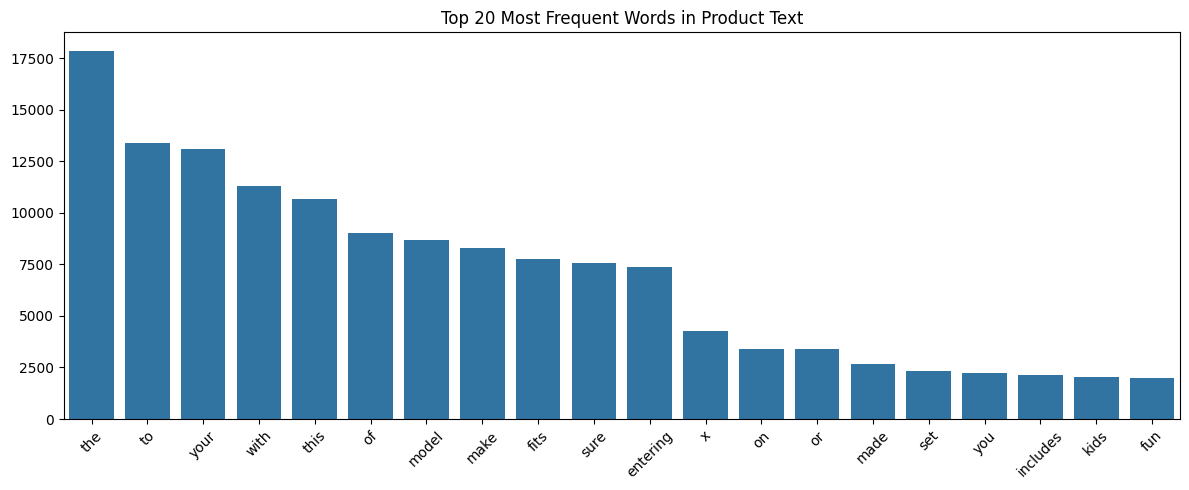

In [ ]:
# Replace NaNs with empty strings before combining
df['Textual Information'] = (
    df['Product Name'].fillna('') + ' ' +
    df['About Product'].fillna('') + ' ' +
    df['Product Specification'].fillna('')
)

# Now repeat tokenization and frequency analysis
tokens = ' '.join(df['Textual Information'].astype(str)).lower().split()
tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
common_words = Counter(tokens).most_common(20)

# Plot top 20 most frequent words
words, freqs = zip(*common_words)
plt.figure(figsize=(12, 5))
sns.barplot(x=list(words), y=list(freqs))
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words in Product Text")
plt.tight_layout()
plt.show()

In [ ]:

def get_actual_category(cat):
    if pd.isna(cat):
        return None
    parts = cat.split(" | ")
    if parts[0] == "Toys & Games":
        return "T&G:" + parts[1] if len(parts) > 1 else None
    else:
        return parts[0]
df['Toys_and_games'] = df['Category'].apply(
    lambda x: True if pd.notna(x) and x.split(" | ")[0] == "Toys & Games" else False
)
df = df[df['Category'].notna()]
df['actual_category'] = df['Category'].apply(get_actual_category)
final_df = df[['Product Name', 'actual_category', 'Textual Information','Toys_and_games']]
final_df

<ipython-input-195-f6cc8521da9f>:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Product Name,actual_category,Textual Information,Toys_and_games
0,"DB Longboards CoreFlex Crossbow 41"" Bamboo Fib...",Sports & Outdoors,"DB Longboards CoreFlex Crossbow 41"" Bamboo Fib...",False
1,"Electronic Snap Circuits Mini Kits Classpack, ...",T&G:Learning & Education,"Electronic Snap Circuits Mini Kits Classpack, ...",True
2,3Doodler Create Flexy 3D Printing Filament Ref...,T&G:Arts & Crafts,3Doodler Create Flexy 3D Printing Filament Ref...,True
3,Guillow Airplane Design Studio with Travel Cas...,T&G:Hobbies,Guillow Airplane Design Studio with Travel Cas...,True
4,Woodstock- Collage 500 pc Puzzle,T&G:Puzzles,Woodstock- Collage 500 pc Puzzle Make sure thi...,True
...,...,...,...,...
9997,Remedia Publications REM536B Money Activity Bo...,T&G:Learning & Education,Remedia Publications REM536B Money Activity Bo...,True
9998,Trends International NFL La Chargers HG - Mobi...,T&G:Arts & Crafts,Trends International NFL La Chargers HG - Mobi...,True
9999,NewPath Learning 10 Piece Science Owls and Owl...,Office Products,NewPath Learning 10 Piece Science Owls and Owl...,False
10000,Disney Princess Do It Yourself Braid Set,T&G:Arts & Crafts,Disney Princess Do It Yourself Braid Set Prod...,True


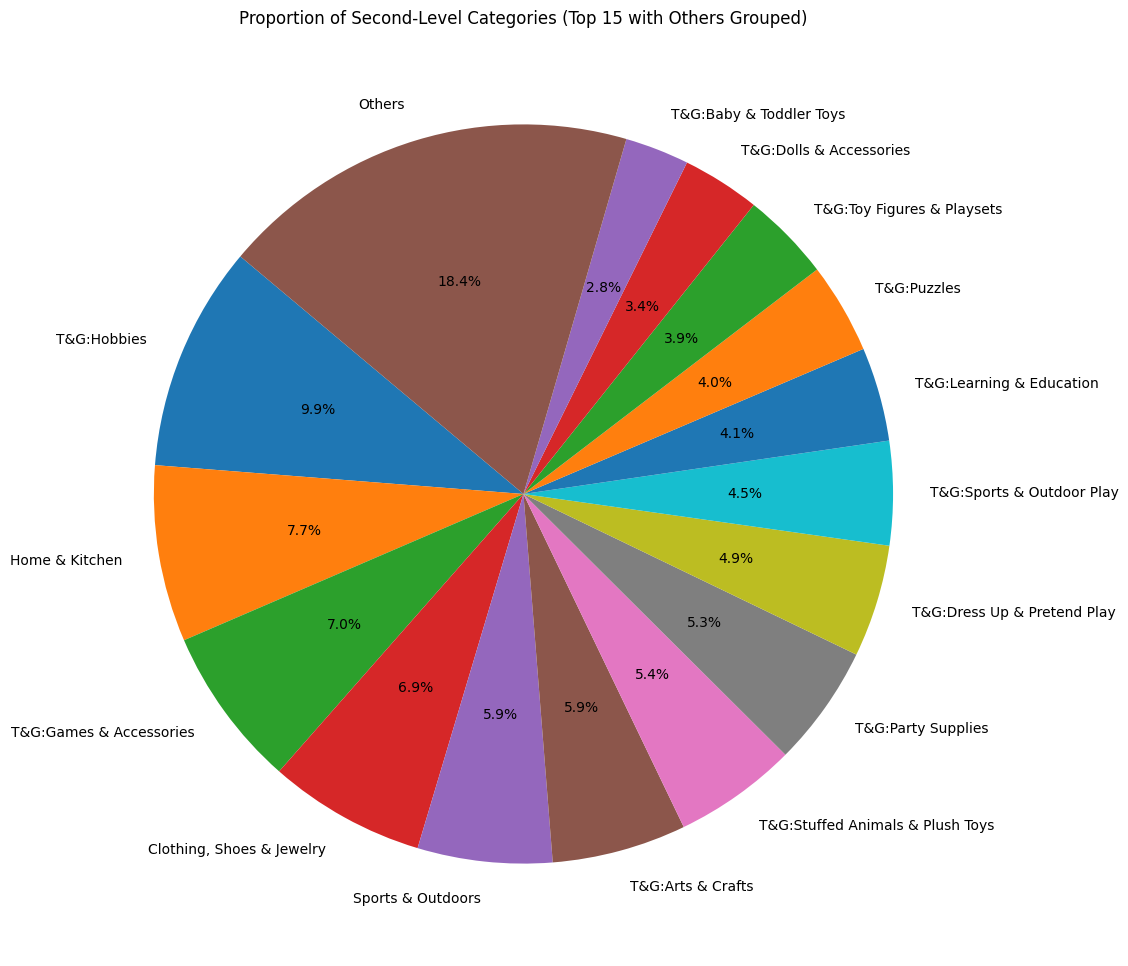

In [ ]:
# Count occurrences of the first categories
category_counts = df['actual_category'].value_counts()

top_categories = category_counts[:15]
other_count = category_counts[15:].sum()

# Append 'Others' category
final_counts = pd.concat([top_categories, pd.Series({'Others': other_count})])

# Plotting the modified pie chart
plt.figure(figsize=(12, 12))
final_counts.plot.pie(autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Second-Level Categories (Top 15 with Others Grouped)')
plt.ylabel('')
plt.show()

In [ ]:
df_visualize = pd.read_csv('amazon2020.csv')

df_visualize = df_visualize[df_visualize["Category"].notna()]
df_visualize["Category"] = df_visualize["Category"].apply(lambda x: x.split(" | "))

Category = {}
SubCategory = {}

for row in df_visualize["Category"]:
  if row[0] in Category:
    Category[row[0]] += 1
  else:
    Category[row[0]] = 1

  if row[1] in SubCategory:
    SubCategory[row[1]][1] += 1
  else:
    SubCategory[row[1]] = [row[0], 1]

for key in SubCategory:
  SubCategory[key][0] = SubCategory[key][0] + " (" + str(Category[SubCategory[key][0]]) + ")"

Category_1 = []
Category_2 = []
Values = []


for key in SubCategory:
  Category_1.append(SubCategory[key][0])
  Category_2.append(key)
  Values.append(SubCategory[key][1])

logValues = np.log1p(Values)
df_treemap = pd.DataFrame({
    "Category": Category_1,
    "Label": Category_2,
    "LogValues": logValues,
    "Values": Values
})

df_treemap["Label"] = df_treemap["Label"] + " (" + df_treemap["Values"].astype(str) + ")"


fig = px.treemap(
    df_treemap,
    path=["Category", "Label"],
    values="LogValues",
    color="Category",
    color_discrete_map={
        "CATEGORY A": "#1f77b4",
        "CATEGORY B": "#ff7f0e",
        "CATEGORY C": "#2ca02c",
        "CATEGORY D": "#17becf"
    },
)

fig.data[0].customdata = df_treemap[["Values"]].values


fig.update_traces(
    hovertemplate="<b>%{label}</b><br><extra></extra>",
    selector=dict(type='treemap')
)

fig.show()

In [ ]:
# tokenlized our textual information
# Define a simple tokenizer using regex and scikit-learn stopwords
def simple_tokenizer(text):
    # Lowercase and remove non-alphabetic characters
    tokens = re.findall(r'\b[a-z]{2,}\b', str(text).lower())
    # Remove stopwords
    filtered = [word for word in tokens if word not in ENGLISH_STOP_WORDS]
    return filtered

# Apply the tokenizer to the "Textual Information" column
final_df['Tokenized_Text'] = final_df['Textual Information'].apply(simple_tokenizer)

# Define the function to stem the tokens
def stem_tokens(tokens):
    """Apply Porter stemmer to each token."""
    stemmer = PorterStemmer()
    return [stemmer.stem(token) for token in tokens]

# Stem the token for training, validating, and testing set
final_df['Tokenized_Text'] = final_df['Tokenized_Text'].apply(stem_tokens)

# Show sample result
final_df.dropna(inplace = True)

<ipython-input-198-3aefe3fe1067>:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-198-3aefe3fe1067>:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-198-3aefe3fe1067>:23: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
# Separate the data in to testing, validation and the training data
# First split: training (60%) and temp (40%)
train_df, temp_df = train_test_split(final_df, test_size=0.4, random_state=42)

# Second split: validation (20%) and testing (20%) from the temp set
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# Confirm the split sizes
split_sizes = {
    "Training Set": len(train_df),
    "Validation Set": len(val_df),
    "Testing Set": len(test_df),
    "Total Rows": len(df)
}

split_sizes

{'Training Set': 5503,
 'Validation Set': 1834,
 'Testing Set': 1835,
 'Total Rows': 9172}

In [ ]:
train_df

,Product Name,actual_category,Textual Information,Toys_and_games,Tokenized_Text
887,Whitmor Frog Collapsible Cube,Home & Kitchen,Whitmor Frog Collapsible Cube Make sure this f...,False,"[whitmor, frog, collaps, cube, make, sure, fit..."
9047,Lando Calrissian Adult Wig and Moustache,"Clothing, Shoes & Jewelry",Lando Calrissian Adult Wig and Moustache 100% ...,False,"[lando, calrissian, adult, wig, moustach, fibe..."
915,HearthSong Children's Potholder Hook and Loop ...,T&G:Arts & Crafts,HearthSong Children's Potholder Hook and Loop ...,True,"[hearthsong, children, pothold, hook, loop, ki..."
9138,BRIO World - 33797 Firefighter Helicopter | 3 ...,T&G:Play Vehicles,BRIO World - 33797 Firefighter Helicopter | 3 ...,True,"[brio, world, firefight, helicopt, piec, helic..."
2663,"Ertl John Deere 850K Diecast Dozer, 1:50-Scale",T&G:Hobbies,"Ertl John Deere 850K Diecast Dozer, 1:50-Scale...",True,"[ertl, john, deer, diecast, dozer, scale, make..."
...,...,...,...,...,...
6323,"MasterPieces NCAA Clemson Tigers, Collectible ...",Sports & Outdoors,"MasterPieces NCAA Clemson Tigers, Collectible ...",False,"[masterpiec, ncaa, clemson, tiger, collect, do..."
5728,VTech Zoo Jamz Piano (Frustration Free Packaging),T&G:Learning & Education,VTech Zoo Jamz Piano (Frustration Free Packagi...,True,"[vtech, zoo, jamz, piano, frustrat, free, pack..."
5949,Roller Derby Girl's Laser Speed Quad Skate,Sports & Outdoors,Roller Derby Girl's Laser Speed Quad Skate Man...,False,"[roller, derbi, girl, laser, speed, quad, skat..."
942,"Jada Venia 9.75""x7.75"" Sherri Ohler Sleigh Lig...",Home & Kitchen,"Jada Venia 9.75""x7.75"" Sherri Ohler Sleigh Lig...",False,"[jada, venia, sherri, ohler, sleigh, light, bo..."


In [ ]:
# Step 1: Join token lists into strings
train_df['Cleaned_Text'] = train_df['Tokenized_Text'].apply(lambda x: ' '.join(x))
val_df['Cleaned_Text'] = val_df['Tokenized_Text'].apply(lambda x: ' '.join(x))

# Step 2: TF-IDF Vectorization (fit only on train, transform on both)
vectorizer =  TfidfVectorizer()
X_train = vectorizer.fit_transform(train_df['Cleaned_Text'])
X_val = vectorizer.transform(val_df['Cleaned_Text'])

# Step 3: Label Encoding
le = LabelEncoder()
y_train = le.fit_transform(train_df['actual_category'].astype(str))
y_val = le.transform(val_df['actual_category'].astype(str))

## Logistic Regression

In [ ]:
# initialize a logistic model
logisticmodel = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000
)

# fit the model
logisticmodel.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



LogisticRegression(max_iter=1000, multi_class='multinomial')

In [ ]:
# calculate accuracy for training and validating set
train_accuracy = accuracy_score(logisticmodel.predict(X_train), y_train)
val_accuracy = accuracy_score(logisticmodel.predict(X_val), y_val)

print('Accuracy on training set:', train_accuracy)
print('Accuracy on validating set:', val_accuracy)

Accuracy on training set: 0.831182991095766
Accuracy on validating set: 0.7153762268266085


## Random Forest

In [ ]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=123)
rf.fit(X_train, y_train)

# Predict on both train and validation
y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)

# Filter labels for classification report
valid_labels = unique_labels(y_val, y_val_pred)
valid_target_names = le.inverse_transform(valid_labels)

# Report
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred, labels=valid_labels, target_names=valid_target_names))

Training Accuracy: 0.8455387970198074
Validation Accuracy: 0.6368593238822247
                                          precision    recall  f1-score   support

                   Arts, Crafts & Sewing       1.00      0.12      0.21        17
                              Automotive       0.00      0.00      0.00         2
                           Baby Products       0.92      0.51      0.66        45
                  Beauty & Personal Care       0.00      0.00      0.00         3
               Clothing, Shoes & Jewelry       0.66      0.89      0.76       130
                             Electronics       0.00      0.00      0.00         2
                  Grocery & Gourmet Food       0.00      0.00      0.00         1
                      Health & Household       0.00      0.00      0.00         3
                                 Hobbies       0.00      0.00      0.00         9
                          Home & Kitchen       0.53      0.77      0.63       115
                 In

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



## Linear SVM (Support Vector Machine)

In [ ]:
# Train
svm = LinearSVC(C=0.01)
svm = LinearSVC()
svm.fit(X_train, y_train)

# === Predict ===
y_train_pred = svm.predict(X_train)
y_val_pred = svm.predict(X_val)

# === Evaluation ===
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

valid_labels = unique_labels(y_val, y_val_pred)
valid_target_names = le.inverse_transform(valid_labels)

print("Training Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)

print("\nTraining Classification Report:")
print(classification_report(y_train, y_train_pred, target_names=le.classes_))

Training Accuracy: 0.9847355987643104
Validation Accuracy: 0.7459105779716467

Training Classification Report:
                                          precision    recall  f1-score   support

                   Arts, Crafts & Sewing       0.96      0.97      0.97        73
                              Automotive       1.00      1.00      1.00         5
                           Baby Products       0.98      1.00      0.99       131
                  Beauty & Personal Care       1.00      1.00      1.00         6
               Cell Phones & Accessories       1.00      1.00      1.00         1
               Clothing, Shoes & Jewelry       0.98      0.99      0.99       388
                             Electronics       1.00      1.00      1.00         3
                  Grocery & Gourmet Food       1.00      1.00      1.00         7
                      Health & Household       1.00      0.93      0.97        15
                                 Hobbies       1.00      0.56      0

In [ ]:
train_df

,Product Name,actual_category,Textual Information,Toys_and_games,Tokenized_Text,Cleaned_Text
887,Whitmor Frog Collapsible Cube,Home & Kitchen,Whitmor Frog Collapsible Cube Make sure this f...,False,"[whitmor, frog, collaps, cube, make, sure, fit...",whitmor frog collaps cube make sure fit enter ...
9047,Lando Calrissian Adult Wig and Moustache,"Clothing, Shoes & Jewelry",Lando Calrissian Adult Wig and Moustache 100% ...,False,"[lando, calrissian, adult, wig, moustach, fibe...",lando calrissian adult wig moustach fiber impo...
915,HearthSong Children's Potholder Hook and Loop ...,T&G:Arts & Crafts,HearthSong Children's Potholder Hook and Loop ...,True,"[hearthsong, children, pothold, hook, loop, ki...",hearthsong children pothold hook loop kit incl...
9138,BRIO World - 33797 Firefighter Helicopter | 3 ...,T&G:Play Vehicles,BRIO World - 33797 Firefighter Helicopter | 3 ...,True,"[brio, world, firefight, helicopt, piec, helic...",brio world firefight helicopt piec helicopt to...
2663,"Ertl John Deere 850K Diecast Dozer, 1:50-Scale",T&G:Hobbies,"Ertl John Deere 850K Diecast Dozer, 1:50-Scale...",True,"[ertl, john, deer, diecast, dozer, scale, make...",ertl john deer diecast dozer scale make sure f...
...,...,...,...,...,...,...
6323,"MasterPieces NCAA Clemson Tigers, Collectible ...",Sports & Outdoors,"MasterPieces NCAA Clemson Tigers, Collectible ...",False,"[masterpiec, ncaa, clemson, tiger, collect, do...",masterpiec ncaa clemson tiger collect doubl do...
5728,VTech Zoo Jamz Piano (Frustration Free Packaging),T&G:Learning & Education,VTech Zoo Jamz Piano (Frustration Free Packagi...,True,"[vtech, zoo, jamz, piano, frustrat, free, pack...",vtech zoo jamz piano frustrat free packag make...
5949,Roller Derby Girl's Laser Speed Quad Skate,Sports & Outdoors,Roller Derby Girl's Laser Speed Quad Skate Man...,False,"[roller, derbi, girl, laser, speed, quad, skat...",roller derbi girl laser speed quad skate man b...
942,"Jada Venia 9.75""x7.75"" Sherri Ohler Sleigh Lig...",Home & Kitchen,"Jada Venia 9.75""x7.75"" Sherri Ohler Sleigh Lig...",False,"[jada, venia, sherri, ohler, sleigh, light, bo...",jada venia sherri ohler sleigh light box inser...


## Multinomial Naive Bayes

In [ ]:
# Vectorize the Input ("Textual_Information")
def preprocessing_dummy(doc):
    return doc

vectorizer_1 = CountVectorizer(
    analyzer = 'word',
    tokenizer = preprocessing_dummy,
    preprocessor = preprocessing_dummy,
    token_pattern = None,
    max_features=2000
)

counts_train = vectorizer_1.fit_transform(train_df['Tokenized_Text'])
counts_val = vectorizer_1.transform(val_df['Tokenized_Text'])


# Make the First Model to predict the first Category
model_1 = MultinomialNB()
model_1.fit(counts_train, train_df['actual_category'])


val_predictions = model_1.predict(counts_val)
top_5_words_probability_NB = np.round(np.exp(np.sort(model_1.feature_log_prob_, axis=1)[:, -5:][:, ::-1]), 4)

training_accuracy = accuracy_score(train_df['actual_category'], model_1.predict(counts_train))
validation_accuracy = accuracy_score(val_df['actual_category'], val_predictions)

print(f"Training Accuracy: {training_accuracy}")
print(f"Validation Accuracy: {validation_accuracy}")
print(classification_report(val_df['actual_category'], val_predictions, digits=3))

Training Accuracy: 0.7872069780119935
Validation Accuracy: 0.6859323882224646
                                          precision    recall  f1-score   support

                   Arts, Crafts & Sewing      0.615     0.471     0.533        17
                              Automotive      0.000     0.000     0.000         2
                           Baby Products      0.769     0.667     0.714        45
                  Beauty & Personal Care      0.000     0.000     0.000         3
               Clothing, Shoes & Jewelry      0.725     0.792     0.757       130
                             Electronics      0.000     0.000     0.000         2
                  Grocery & Gourmet Food      0.000     0.000     0.000         1
                      Health & Household      0.000     0.000     0.000         3
                                 Hobbies      0.294     0.556     0.385         9
                          Home & Kitchen      0.759     0.765     0.762       115
                 In

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [ ]:
most_probable_word = vectorizer_1.get_feature_names_out()[np.argsort(model_1.feature_log_prob_, axis=1)[:, -5:][:, ::-1]]
class_labels = model_1.classes_

top_5_words = pd.DataFrame({
    "class": class_labels,
    "top_words": [list(words) for words in most_probable_word]
})
top_5_words.head()

,class,top_words
0,"Arts, Crafts & Sewing","[bead, perler, asin, make, paper]"
1,Automotive,"[productdimens, shippingweight, viewshippingra..."
2,Baby Products,"[wall, decal, room, inch, usa]"
3,Beauty & Personal Care,"[surpris, costum, fun, nail, rubi]"
4,Cell Phones & Accessories,"[phone, attach, charm, make, strap]"


## Long Short-Term Memory Model

In [ ]:
df_copy = final_df.copy()
df_copy["actual_category"] = df_copy["actual_category"].apply(lambda x: "Toys & Games:" if x.startswith("T&G:") else x)

label_encoder = LabelEncoder()
df_copy['Category_Encoded'] = label_encoder.fit_transform(df_copy['actual_category'])
label_mapping = {idx: label for idx, label in enumerate(label_encoder.classes_)}

tokenizer = Tokenizer(num_words=5000, oov_token='<OOV>')
tokenizer.fit_on_texts(df_copy['Tokenized_Text'])
sequences = tokenizer.texts_to_sequences(df_copy['Tokenized_Text'])

max_len = 150
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

X_train, X_temp, y_train, y_temp = train_test_split(
    padded_sequences, df_copy['Category_Encoded'], test_size=0.2, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

model = Sequential()

# We use embedding with input dim (Same as vocabulary in tokenizer), and mask_zero = True (So the model doesn't learn from 'padded' token)
model.add(Embedding(input_dim=5000, output_dim=64, input_length=max_len, mask_zero=True))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dense(len(df_copy['actual_category'].unique()), activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

preds = model.predict(X_test)
predicted_classes = np.argmax(preds, axis=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning:

Argument `input_length` is deprecated. Just remove it.



Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 39s 125ms/step - accuracy: 0.6847 - loss: 1.7069 - val_accuracy: 0.7448 - val_loss: 0.9666
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 25s 108ms/step - accuracy: 0.7399 - loss: 0.9538 - val_accuracy: 0.8059 - val_loss: 0.7752
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 41s 109ms/step - accuracy: 0.8025 - loss: 0.7747 - val_accuracy: 0.8375 - val_loss: 0.6586
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 41s 108ms/step - accuracy: 0.8371 - loss: 0.6319 - val_accuracy: 0.8397 - val_loss: 0.6301
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 40s 104ms/step - accuracy: 0.8792 - loss: 0.4696 - val_accuracy: 0.8484 - val_loss: 0.6178
Epoch 6/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 42s 112ms/step - accuracy: 0.8791 - loss: 0.4593 - val_accuracy: 0.8506 - val_loss: 0.6153
Epoch 7/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 25s 108ms/step - accuracy: 0.8900 - loss: 0.3943 - val_accuracy: 0.8550 - val_loss: 0.6240
Epoch 8/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 41s 108ms/step - accuracy: 0.9028 - loss: 0

In [ ]:
predicted_classes_report = pd.Series(predicted_classes).replace(label_mapping).to_numpy()
print(classification_report(y_test.replace(label_mapping), predicted_classes_report, digits=3))

                                          precision    recall  f1-score   support

                   Arts, Crafts & Sewing      0.000     0.000     0.000        18
                              Automotive      0.000     0.000     0.000         3
                           Baby Products      0.733     0.579     0.647        19
                  Beauty & Personal Care      0.000     0.000     0.000         1
               Clothing, Shoes & Jewelry      0.720     0.844     0.777        64
                      Health & Household      0.000     0.000     0.000         2
                                 Hobbies      0.000     0.000     0.000         3
                          Home & Kitchen      0.708     0.818     0.759        77
                 Industrial & Scientific      1.000     0.333     0.500         3
                         Office Products      0.500     0.333     0.400         3
                    Patio, Lawn & Garden      0.000     0.000     0.000         1
               

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

